# Part 1 — Data Cleaning & Data Quality

This section focuses on understanding the raw Airbnb dataset, identifying data quality issues, correcting inconsistent formats, and preparing the data for further analysis.

The main areas covered are missing values, data types, inconsistent categories, duplicate records, and unusual values.

## 1. Import Libraries

The analysis will use Pandas and NumPy for data loading, cleaning, transformation, and numerical analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

The Airbnb dataset is loaded from the local system and stored in the DataFrame `df`.

In [2]:
file_path = r"C:\Users\hp\Downloads\airbnb (1).csv"

df = pd.read_csv(file_path)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns="Unnamed: 0")

df

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,"Manhattan, Harlem","(40.80379, -73.95257)",Entire home/apt,105$,4,2018-05-28,0.21,0,4.757555,4.8,0.639223,2017-11-22
10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,"Manhattan, East Harlem","(40.79531, -73.9333)",Entire home/apt,125$,50,2018-05-06,0.66,188,4.344704,60.0,0.648778,2017-10-31
10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,"Brooklyn, Clinton Hill","(40.68266, -73.96743000000002)",Entire home/apt,100$,45,2016-11-27,0.98,0,3.966214,54.0,0.631713,2016-05-24
10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,"Brooklyn, Clinton Hill","(40.68832, -73.96366)",Entire home/apt,450$,2,2019-05-31,0.17,99,4.078581,2.4,0.703360,2018-11-25


The dataset has been successfully loaded into **`df`**.

In [3]:
df.shape

(10019, 16)

The dataset contains 10,019 listings and 17 columns.

## 3. Missing Values Analysis

Before cleaning the dataset, missing values are checked across all columns. Both the number and percentage of missing values are calculated to understand the extent of the data quality issue.

In [4]:
# Check for missing values and empty strings
missing_values = df.isna().sum()

empty_strings = df.select_dtypes(include="object").apply(
    lambda col: col.astype(str).str.strip().eq("").sum()
)

total_missing = missing_values.copy()
total_missing.loc[empty_strings.index] += empty_strings

missing_summary = pd.DataFrame({
    "missing_values": total_missing,
    "missing_percentage": (total_missing / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_values"] > 0
].sort_values("missing_percentage", ascending=False)

missing_summary

,missing_values,missing_percentage
last_review,2075,20.71
number_of_stays,2075,20.71
rating,2075,20.71
reviews_per_month,2075,20.71
5_stars,2075,20.71
price,238,2.38
name,5,0.05
host_name,2,0.02


### Finding

The largest missing-value issue occurs in the review-related columns, where 2,075 listings (20.71%) have missing values.

The price column has 238 missing values (2.38%), while only a very small number of listings have missing names or host names.

The review-related missing values are strongly associated with listings that have never received a review, so they should not be blindly replaced with mean or median values.

## 4. Zero-Review Listings

Listings with zero reviews are checked to determine whether the missing review-related fields represent actual missing information or a meaningful absence of activity.

In [5]:
zero_review = df["number_of_reviews"] == 0

zero_review_count = zero_review.sum()
zero_review_percentage = zero_review.mean() * 100

zero_review_count, round(zero_review_percentage, 2)

(np.int64(2075), np.float64(20.71))

In [6]:
review_columns = [
    "last_review",
    "reviews_per_month",
    "rating",
    "number_of_stays",
    "5_stars"
]

df.loc[zero_review, review_columns].notna().sum()

last_review          0
reviews_per_month    0
rating               0
number_of_stays      0
5_stars              0
dtype: int64

### Finding

There are 2,075 listings with zero reviews, representing 20.71% of the dataset.

For these listings, **`last_review`**, **`reviews_per_month`**, **`rating`**, **`number_of_stays`**, and **`5_stars`** are consistently missing.

These values should be left as NaN because missing information here has a meaningful reason: the listing has not received any reviews.

Replacing these values with zero or the median would create artificial information. For example, assigning the median rating to a listing with no reviews would incorrectly suggest that the listing has been rated.

## 5. Missing Price Values

Price is an important analytical variable, so missing price values need to be investigated before performing price-based analysis.

In [7]:
missing_price = df["price"].isna()

missing_price_count = missing_price.sum()
missing_price_percentage = missing_price.mean() * 100

missing_price_count, round(missing_price_percentage, 2)

(np.int64(238), np.float64(2.38))

### Finding

238 listings (2.38%) have missing price values.

Because the percentage is relatively small, these records should not be deleted automatically.

The preferred approach is to impute the missing price using the median price of listings with the same **`room_type`** and **`neighbourhood_full`**.

If that group does not contain enough valid prices, the fallback will be the median price for the same room type, followed by the overall median price.

## 6. Price Data Type Cleaning

The **`price`** column is stored as text because values contain a dollar sign, such as **`45$`** and **`150$`**.

The dollar sign will be removed and the column will be converted to a numeric datatype.

In [8]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

In [9]:
df["price"].dtype

dtype('float64')

### Finding

The **`price`** column has been converted from text to numeric format.

This allows price-based calculations, statistical analysis, grouping, and visualization to be performed correctly.

## 7. Date Conversion

The **`listing_added`** and **`last_review`** columns are currently stored as date strings.

They will be converted into Pandas datetime format so that date differences, monthly trends, and recency metrics can be calculated later.

In [10]:
df["listing_added"] = pd.to_datetime(df["listing_added"], errors="coerce")
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

In [11]:
df[["listing_added", "last_review"]].dtypes

listing_added    datetime64[ns]
last_review      datetime64[ns]
dtype: object

### Finding

Both date columns are now stored as datetime values.

Missing values in **`last_review`** remain NaN because they correspond mainly to listings without reviews.

## 8. Coordinate Extraction

The **`coordinates`** column contains latitude and longitude together in a string format such as **`(40.63222, -73.93398)`**.

The values will be split into separate numeric columns so they can later be used for geographic analysis and mapping.

In [12]:
coordinates = df["coordinates"].str.strip("()").str.split(",", expand=True)

df["latitude"] = pd.to_numeric(coordinates[0], errors="coerce")
df["longitude"] = pd.to_numeric(coordinates[1], errors="coerce")

In [13]:
df[["coordinates", "latitude", "longitude"]].head()

,coordinates,latitude,longitude
0,"(40.63222, -73.93398)",40.63222,-73.93398
1,"(40.78761, -73.96862)",40.78761,-73.96862
2,"(40.7007, -73.99517)",40.70070,-73.99517
3,"(40.79169, -73.97498)",40.79169,-73.97498
4,"(40.71884, -73.98354)",40.71884,-73.98354


### Finding

Latitude and longitude have been extracted into separate numeric columns.

The original **`coordinates`** column can be retained for validation and removed later if it is no longer required.

## 9. Room Type Standardization

The **`room_type`** column contains inconsistent labels for the same type of accommodation.

Examples include **`Private room`**, **`PRIVATE ROOM`**, **`Private`**, **`home`**, and values containing unnecessary spaces.

These values will be standardized into three consistent categories:

- **Entire home/apt**
- **Private room**
- **Shared room**

In [14]:
df["room_type"] = df["room_type"].str.strip().str.lower()

room_type_mapping = {
    "private room": "Private room",
    "private": "Private room",
    "entire home/apt": "Entire home/apt",
    "home": "Entire home/apt",
    "shared room": "Shared room"
}

df["room_type"] = df["room_type"].map(room_type_mapping)

# Validate room_type standardization
unexpected_room_types = df["room_type"].isna().sum()

print(f"Unmapped room_type values: {unexpected_room_types}")

if unexpected_room_types == 0:
    print("All room_type values were successfully standardized.")

Unmapped room_type values: 0
All room_type values were successfully standardized.


In [15]:
df["room_type"].value_counts()

room_type
Entire home/apt    5186
Private room       4607
Shared room         226
Name: count, dtype: int64

### Finding

The inconsistent room type labels have been consolidated into three standardized categories.

This prevents categories such as **`Private`**, **`PRIVATE ROOM`**, and **`Private room`** from being treated as separate groups during analysis.

## 10. Borough and Neighborhood Extraction

The **`neighbourhood_full`** column contains two levels of geographic information in a single field, such as **`Brooklyn, Flatlands`**.

The value will be split into separate **`borough`** and **`neighborhood`** columns to make geographic analysis easier.

In [16]:
location = df["neighbourhood_full"].str.split(",", n=1, expand=True)

df["borough"] = location[0].str.strip()
df["neighborhood"] = location[1].str.strip()

In [17]:
df[["neighbourhood_full", "borough", "neighborhood"]].head()

,neighbourhood_full,borough,neighborhood
0,"Brooklyn, Flatlands",Brooklyn,Flatlands
1,"Manhattan, Upper West Side",Manhattan,Upper West Side
2,"Brooklyn, Brooklyn Heights",Brooklyn,Brooklyn Heights
3,"Manhattan, Upper West Side",Manhattan,Upper West Side
4,"Manhattan, Lower East Side",Manhattan,Lower East Side


### Finding

The combined geographic field has been separated into `borough` and `neighborhood`.

This structure will make it easier to compare prices, ratings, availability, and reviews at both borough and neighborhood levels.

## 11. Duplicate Record Validation

Duplicate rows and duplicate listing IDs are checked separately.

An exact duplicate row and a repeated listing ID are not necessarily the same problem, so both checks are required.

In [18]:
exact_duplicates = df.duplicated().sum()
duplicate_listing_ids = df.loc[
    df["listing_id"].duplicated(keep=False),
    "listing_id"
].nunique()

exact_duplicates, duplicate_listing_ids

(np.int64(13), 20)

In [19]:
duplicate_ids = df.loc[
    df["listing_id"].duplicated(keep=False),
    "listing_id"
].unique()

len(duplicate_ids)

20

### Duplicate Listing ID Finding

20 unique listing IDs appear more than once in the raw dataset.

These repeated IDs account for 40 records in total. After removing exact duplicate rows, 7 listing IDs still contain conflicting information.

The 13 exact duplicate rows were removed. The 7 conflicting listing IDs were retained because the dataset does not provide sufficient information to determine which record represents the correct listing version.

Therefore, `listing_id` is not treated as a guaranteed unique identifier for the final analytical dataset.

### Finding

After removing the technical index column, 13 exact duplicate rows were identified and removed.

In addition, 20 listing IDs appear more than once. Of these, 13 represent identical duplicate records, while 7 contain conflicting information.

The identical duplicate records were removed. The conflicting listing IDs were retained because there is insufficient evidence to determine which version is correct.

In [20]:
df = df.drop_duplicates()

- Exact duplicate row → Remove
- Repeated listing_id with identical information → Keep one
- Repeated listing_id with conflicting information → Retain and document as unresolved

## 12. Price Outlier Detection

The price distribution contains some unusually high values, including prices above $1,000.

These values should not be removed automatically because high prices may represent legitimate luxury listings.

The first step is to identify statistical outliers using the IQR method and then investigate them.

In [21]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

price_outliers = df[df["price"] > upper_limit]

print("Q1:", Q1)
print("Q3:", Q3)
print("Upper limit:", upper_limit)
print("Number of price outliers:", len(price_outliers))

Q1: 69.0
Q3: 180.0
Upper limit: 346.5
Number of price outliers: 559


### Finding

The median price is approximately $105, while the mean price is approximately $149.85.

The mean being higher than the median indicates a strongly right-skewed price distribution.

Using the IQR method, prices above $346.50 are statistically flagged as outliers. However, these values should not automatically be treated as errors because some may represent genuine luxury listings.

The outliers are therefore flagged for analysis rather than automatically deleted.

## Create Outlier Flag

In [22]:
df = df.copy()

df.loc[:, "price_outlier_flag"] = df["price"] > upper_limit

df["price_outlier_flag"]

0        False
1        False
2        False
3        False
4        False
         ...  
10014    False
10015    False
10016    False
10017     True
10018    False
Name: price_outlier_flag, Length: 10006, dtype: bool

In [23]:
(df["price"] == 0).sum()

np.int64(2)

A price of 0 is more suspicious than a high luxury price and should be separately investigated as a possible data-entry or collection issue.

## 13. Number of Stays Precision

The **`number_of_stays`** column contains decimal values and some values show floating-point precision artifacts such as **`7.1999999999999975`**.

These artifacts are caused by floating-point representation and do not represent meaningful additional precision.

In [24]:
df = df.copy()

df.loc[:, "number_of_stays"] = df["number_of_stays"].round(1)

df["number_of_stays"]

0        12.0
1         1.2
2         NaN
3         6.0
4        27.6
         ... 
10014     4.8
10015    60.0
10016    54.0
10017     2.4
10018     1.2
Name: number_of_stays, Length: 10006, dtype: float64

In [25]:
df["number_of_stays"].head(10)

0     12.0
1      1.2
2      NaN
3      6.0
4     27.6
5    243.6
6      NaN
7      2.4
8      6.0
9      9.6
Name: number_of_stays, dtype: float64

### Finding

The **`number_of_stays`** values are rounded to one decimal place.

The values are not converted to integers because the dataset contains meaningful decimal values such as 6.0, 27.6, and 243.6.

## 14. Investigation of Missing Price Record

A specific record with a missing price and a relatively high number of reviews is investigated separately.

This helps determine whether the missing value is an isolated data quality issue.

In [26]:
df[df["listing_id"] == 7116071]

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,...,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighborhood,price_outlier_flag
172,7116071,30 Minutes to Manhattan / Sleeps 7,36903907,Moe,"Brooklyn, Bensonhurst","(40.61112, -74.00028)",Entire home/apt,NaN,207,2019-07-02,...,287,3.990992,248.4,0.685576,2018-12-27,40.61112,-74.00028,Brooklyn,Bensonhurst,False


### Finding

The listing has 207 reviews, a rating, a recent review date, and 248.4 estimated stays, so the listing itself is clearly active in the dataset.

The missing price is therefore best treated as a missing data value rather than evidence that the listing is invalid.

The record should not be removed simply because its price is missing.

The price will be imputed using the predefined hierarchical strategy:

1. Median price for the same room type and neighborhood
2. Room type median if the first group is unavailable
3. Overall median as the final fallback

## 15. Price Imputation

Missing prices will be filled using a hierarchical median strategy.

The neighborhood and room type provide a more relevant reference price than using the overall median for every missing record.

In [27]:
# Treat zero prices as missing values
df.loc[df["price"] == 0, "price"] = np.nan

# Track prices that were missing or invalid
df["price_was_imputed"] = df["price"].isna()

# Impute using room_type + neighbourhood_full median
group_median = df.groupby(
    ["room_type", "neighbourhood_full"]
)["price"].transform("median")

df["price"] = df["price"].fillna(group_median)

# Fallback: room_type median
room_median = df.groupby("room_type")["price"].transform("median")

df["price"] = df["price"].fillna(room_median)

# Final fallback: overall median
df["price"] = df["price"].fillna(df["price"].median())

In [28]:
df["price"].isna().sum()

np.int64(0)

### Finding

All missing and invalid price values have been handled using a hierarchical median imputation strategy based on room type and neighbourhood.

The original missing or invalid price records are preserved through the **`price_was_imputed`** flag, allowing them to be identified during later analysis.

## 16. Final Data Quality Check

After completing the cleaning steps, the dataset is checked again for remaining missing values, data types, duplicate rows, and basic structural consistency.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10006 entries, 0 to 10018
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   listing_id          10006 non-null  int64         
 1   name                10001 non-null  object        
 2   host_id             10006 non-null  int64         
 3   host_name           10004 non-null  object        
 4   neighbourhood_full  10006 non-null  object        
 5   coordinates         10006 non-null  object        
 6   room_type           10006 non-null  object        
 7   price               10006 non-null  float64       
 8   number_of_reviews   10006 non-null  int64         
 9   last_review         7932 non-null   datetime64[ns]
 10  reviews_per_month   7932 non-null   float64       
 11  availability_365    10006 non-null  int64         
 12  rating              7932 non-null   float64       
 13  number_of_stays     7932 non-null   float64       


In [30]:
df.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
coordinates              0
room_type                0
price                    0
number_of_reviews        0
last_review           2074
reviews_per_month     2074
availability_365         0
rating                2074
number_of_stays       2074
5_stars               2074
listing_added            0
latitude                 0
longitude                0
borough                  0
neighborhood             0
price_outlier_flag       0
price_was_imputed        0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.shape

(10006, 22)

## Part 1 Summary

The raw Airbnb dataset has been cleaned and validated.

Key actions completed:

- Missing values were identified and assessed.
- Review-related NaN values for zero-review listings were preserved.
- Missing prices were imputed using a hierarchical median strategy.
- Price values were converted to numeric format.
- Date columns were converted to datetime.
- Coordinates were split into latitude and longitude.
- Room type categories were standardized.
- Borough and neighborhood were extracted.
- Duplicate rows were checked.
- Repeated listing IDs were investigated rather than blindly removed.
- Price outliers were identified and flagged instead of automatically deleted.
- Floating-point artifacts in **`number_of_stays`** were rounded to one decimal place.

The resulting dataset is now ready for Part 2 — Data Wrangling and Feature Engineering.

# Part 2 — Data Wrangling & Feature Engineering

This section transforms the cleaned dataset into an analysis-ready dataset by creating useful analytical features.

The features focus on geographic segmentation, review activity, review recency, price segmentation, host portfolio size, stay intensity, and estimated revenue.

Some derived metrics are treated as analytical proxies rather than verified business measures because the dataset does not provide direct occupancy or revenue information.

### Create an independent copy for feature engineering

In [33]:
df = df.copy()

## 1. Borough and Neighborhood Validation

The **`borough`** and **`neighborhood`** columns were extracted from **`neighbourhood_full`** during data cleaning in Part 1.

These existing columns are reused in Part 2 for geographic grouping and feature engineering.

No additional geographic transformation is performed here to avoid duplicating the Part 1 cleaning step.

### Verify the extracted geographic columns

In [34]:
df[
    [
        "neighbourhood_full",
        "borough",
        "neighborhood"
    ]
].head()

,neighbourhood_full,borough,neighborhood
0,"Brooklyn, Flatlands",Brooklyn,Flatlands
1,"Manhattan, Upper West Side",Manhattan,Upper West Side
2,"Brooklyn, Brooklyn Heights",Brooklyn,Brooklyn Heights
3,"Manhattan, Upper West Side",Manhattan,Upper West Side
4,"Manhattan, Lower East Side",Manhattan,Lower East Side


In [35]:
print("Borough column exists:", "borough" in df.columns)
print("Neighborhood column exists:", "neighborhood" in df.columns)

Borough column exists: True
Neighborhood column exists: True


### Finding

The **`borough`** and **`neighborhood`** columns were successfully created during Part 1 and are available for reuse.

No new geographic feature is required in this section.

## 2. Review Recency

A **`days_since_last_review`** feature is created to measure the recency of the most recent review received by each listing.

The latest available **`last_review`** date in the dataset is used as the reference date instead of today's date.

Using the dataset's latest review date keeps the calculation reproducible and ensures that the feature remains consistent when the analysis is rerun.

Listings without a recorded review date retain **`NaN`** because their review recency cannot be calculated.

In [36]:
reference_date = df["last_review"].max()

df["days_since_last_review"] = (
    reference_date - df["last_review"]
).dt.days

In [37]:
print("Reference date:", reference_date)
print(
    "Missing recency values:",
    df["days_since_last_review"].isna().sum()
)

Reference date: 2019-07-08 00:00:00
Missing recency values: 2074


In [38]:
df[
    [
        "last_review",
        "days_since_last_review"
    ]
].head(10)

,last_review,days_since_last_review
0,2018-12-12,208.0
1,2019-06-30,8.0
2,NaT,NaN
3,2017-09-23,653.0
4,2019-06-12,26.0
5,2019-06-20,18.0
6,NaT,NaN
7,2018-06-22,381.0
8,2017-06-25,743.0
9,2019-04-24,75.0


### Finding

The **`days_since_last_review`** feature provides a consistent measure of review recency using the latest available review date in the dataset as the reference point.

Listings without reviews remain `NaN` because no review date is available for calculating recency.

## 3. Price-Based Analytical Proxies

Two derived ratios are created to support exploratory comparisons.

**`price_per_review`** compares listing price with the number of reviews, while **`price_per_stay`** compares listing price with the estimated number of stays.

These metrics are treated as analytical proxies rather than direct measures of listing profitability or efficiency because reviews and stays do not necessarily represent the same unit of economic activity.

Listings with zero reviews or zero estimated stays receive **`NaN`** rather than zero because division by zero does not provide a meaningful interpretation.

In [39]:
df["price_per_review"] = np.where(
    df["number_of_reviews"] > 0,
    df["price"] / df["number_of_reviews"],
    np.nan
)

df["price_per_stay"] = np.where(
    df["number_of_stays"] > 0,
    df["price"] / df["number_of_stays"],
    np.nan
)

In [40]:
df[
    [
        "price",
        "number_of_reviews",
        "number_of_stays",
        "price_per_review",
        "price_per_stay"
    ]
].head(10)

,price,number_of_reviews,number_of_stays,price_per_review,price_per_stay
0,45.0,10,12.0,4.500000,3.750000
1,135.0,1,1.2,135.000000,112.500000
2,150.0,0,NaN,NaN,NaN
3,86.0,5,6.0,17.200000,14.333333
4,160.0,23,27.6,6.956522,5.797101
5,150.0,203,243.6,0.738916,0.615764
6,200.0,0,NaN,NaN,NaN
7,224.0,2,2.4,112.000000,93.333333
8,169.0,5,6.0,33.800000,28.166667
9,75.0,8,9.6,9.375000,7.812500


In [41]:
print(
    "Missing price_per_review values:",
    df["price_per_review"].isna().sum()
)

print(
    "Missing price_per_stay values:",
    df["price_per_stay"].isna().sum()
)

Missing price_per_review values: 2074
Missing price_per_stay values: 2074


### Finding

The price-based ratios have been created for exploratory comparison.

Zero-review listings retain **`NaN`** for **`price_per_review`**, and listings with zero or missing estimated stays retain **`NaN`** for **`price_per_stay`**.

These measures should be interpreted as analytical proxies rather than verified business efficiency metrics.

## 4. Review Activity Flag

A binary **`has_reviews`** flag is created to distinguish listings that have received at least one review from listings that have never received a review.

This feature enables segmentation of listings into reviewed and never-reviewed groups during exploratory analysis.

In [42]:
df["has_reviews"] = (
    df["number_of_reviews"] > 0
).astype(int)

In [43]:
df["has_reviews"].value_counts().sort_index()

has_reviews
0    2074
1    7932
Name: count, dtype: int64

In [44]:
print("Listings without reviews:", (df["has_reviews"] == 0).sum())
print("Listings with reviews:", (df["has_reviews"] == 1).sum())

Listings without reviews: 2074
Listings with reviews: 7932


### Finding

**`has_reviews = 1`** indicates that a listing has received at least one review.

**`has_reviews = 0`** indicates that the listing has never received a review.

This feature will be useful for comparing pricing, availability, host characteristics, and other listing attributes between reviewed and never-reviewed listings.

## 5. Five-Star Percentage and Rating Category

The **`5_stars`** column represents the proportion of ratings that are five-star ratings.

The original proportion is retained, while a percentage-based feature is created for easier interpretation.

A categorical rating segmentation is also created using three groups:

- Low: below 60%
- Medium: 60% to below 80%
- High: 80% or above

The numerical percentage remains the primary analytical feature, while the categorical version is used for segmentation.

In [45]:
df["five_star_percentage"] = (
    df["5_stars"] * 100
)

In [46]:
df["five_star_category"] = pd.cut(
    df["five_star_percentage"],
    bins=[-np.inf, 60, 80, np.inf],
    labels=["Low", "Medium", "High"],
    right=False
)

In [47]:
df[
    [
        "5_stars",
        "five_star_percentage",
        "five_star_category"
    ]
].head(10)

,5_stars,five_star_percentage,five_star_category
0,0.609432,60.943150,Medium
1,0.746135,74.613459,Medium
2,NaN,NaN,NaN
3,0.769947,76.994708,Medium
4,0.649383,64.938307,Medium
5,0.743500,74.349970,Medium
6,NaN,NaN,NaN
7,0.690393,69.039331,Medium
8,0.704538,70.453799,Medium
9,0.750073,75.007342,Medium


In [48]:
df["five_star_category"].value_counts().sort_index()

five_star_category
Low          0
Medium    6878
High      1054
Name: count, dtype: int64

### Finding

The original **`5_stars`** proportion has been retained, while **`five_star_percentage`** provides a more intuitive percentage-based representation.

The **`five_star_category`** feature provides a simple segmentation into Low, Medium, and High five-star rating proportions.

The numerical percentage should be preferred when performing detailed quantitative analysis.

## 6. Price Segmentation

Listings are grouped into three price segments to simplify comparisons across different pricing levels.

- Budget: below $100
- Mid-range: $100 to $300
- Luxury: above $300

In [49]:
df["price_category"] = np.select(
    [
        df["price"] < 100,
        df["price"].between(100, 300, inclusive="both"),
        df["price"] > 300
    ],
    [
        "Budget",
        "Mid-range",
        "Luxury"
    ],
    default=None
)

In [50]:
df["price_category"].value_counts().sort_index()

price_category
Budget       4505
Luxury        651
Mid-range    4850
Name: count, dtype: int64

In [51]:
df[
    [
        "price",
        "price_category"
    ]
].head(10)

,price,price_category
0,45.0,Budget
1,135.0,Mid-range
2,150.0,Mid-range
3,86.0,Budget
4,160.0,Mid-range
5,150.0,Mid-range
6,200.0,Mid-range
7,224.0,Mid-range
8,169.0,Mid-range
9,75.0,Budget


### Finding

The listings have been segmented into Budget, Mid-range, and Luxury price categories.

This segmentation will support comparative analysis of listing activity, reviews, availability, host characteristics, and other analytical features.

## 7. Estimated Occupancy Proxy

An estimated occupancy ratio is derived using **`number_of_stays`** and **`availability_365`**.

The calculation uses:

**`number_of_stays / (365 - availability_365)`**

This metric is treated strictly as an analytical proxy rather than a verified occupancy rate.

The dataset does not explicitly establish that **`number_of_stays`** represents occupied nights or that it uses exactly the same time basis as **`availability_365`**.

Listings where the available-day denominator is zero or required values are missing retain **`NaN`**.

In [52]:
available_days = 365 - df["availability_365"]

df["occupancy_estimate"] = np.where(
    (available_days > 0) &
    df["number_of_stays"].notna(),
    df["number_of_stays"] / available_days,
    np.nan
)

In [53]:
df[
    [
        "availability_365",
        "number_of_stays",
        "occupancy_estimate"
    ]
].head(10)

,availability_365,number_of_stays,occupancy_estimate
0,85,12.0,0.042857
1,145,1.2,0.005455
2,65,NaN,NaN
3,0,6.0,0.016438
4,102,27.6,0.104943
5,300,243.6,3.747692
6,219,NaN,NaN
7,353,2.4,0.200000
8,365,6.0,NaN
9,9,9.6,0.026966


In [54]:
print(
    "Missing occupancy proxy values:",
    df["occupancy_estimate"].isna().sum()
)

Missing occupancy proxy values: 2272


### Finding

The **`occupancy_estimate`** feature provides an analytical proxy based on the available stay and availability variables.

It should not be interpreted as verified occupancy because the dataset does not directly provide occupied nights or a confirmed occupancy calculation.

The ratio is retained in its original form rather than automatically converted into a percentage.

## 8. Host Portfolio Size

The number of listings associated with each **`host_id`** is calculated to identify the size of each host's listing portfolio.

Hosts are then classified into two groups:

- Single-listing host: one listing
- Multi-property host: more than one listing

This feature helps investigate whether listing characteristics differ between individual hosts and hosts managing multiple properties.

In [55]:
df["host_listing_count"] = (
    df.groupby("host_id")["listing_id"]
    .transform("count")
)

In [56]:
df["host_type"] = np.where(
    df["host_listing_count"] == 1,
    "Single-listing host",
    "Multi-property host"
)

In [57]:
df[
    [
        "host_id",
        "host_listing_count",
        "host_type"
    ]
].head(10)

,host_id,host_listing_count,host_type
0,20583125,1,Single-listing host
1,82746113,1,Single-listing host
2,78251,1,Single-listing host
3,32715865,1,Single-listing host
4,154262349,1,Single-listing host
5,1423798,1,Single-listing host
6,33388853,1,Single-listing host
7,78824908,1,Single-listing host
8,3191545,6,Multi-property host
9,68557372,1,Single-listing host


In [58]:
df["host_type"].value_counts()

host_type
Single-listing host    8343
Multi-property host    1663
Name: count, dtype: int64

### Finding

The host portfolio size has been calculated using the number of listings associated with each **`host_id`**.

Hosts managing one listing are classified as **`Single-listing host`**, while hosts managing more than one listing are classified as **`Multi-property host`**.

This segmentation can later be used to compare pricing, availability, reviews, and other listing characteristics across host types.

## 9. Estimated Revenue Proxy

A simplified revenue estimate is derived by multiplying listing price by the estimated number of stays.

The calculation is:

**`price × number_of_stays`**

This metric is treated as a revenue proxy rather than actual realized revenue.

The dataset does not provide verified booking revenue, stay duration, cleaning fees, taxes, discounts, service fees, or other revenue components.

In [59]:
df["revenue_estimate"] = (
    df["price"] *
    df["number_of_stays"]
)

In [60]:
df[
    [
        "price",
        "number_of_stays",
        "revenue_estimate"
    ]
].head(10)

,price,number_of_stays,revenue_estimate
0,45.0,12.0,540.0
1,135.0,1.2,162.0
2,150.0,NaN,NaN
3,86.0,6.0,516.0
4,160.0,27.6,4416.0
5,150.0,243.6,36540.0
6,200.0,NaN,NaN
7,224.0,2.4,537.6
8,169.0,6.0,1014.0
9,75.0,9.6,720.0


In [61]:
print(
    "Missing revenue proxy values:",
    df["revenue_estimate"].isna().sum()
)

Missing revenue proxy values: 2074


### Finding

The **`revenue_estimate`** feature provides a simplified proxy for potential listing-level revenue based on price and estimated stays.

It should be used for relative comparisons only and should not be interpreted as actual realized revenue.

## 10. Final Feature Engineering Audit

The newly created and reused features are validated to ensure that all required analytical features are available in the dataset.

The audit checks both feature existence and missing-value counts.

In [62]:
required_features = [
    "borough",
    "neighborhood",
    "days_since_last_review",
    "price_per_review",
    "price_per_stay",
    "has_reviews",
    "five_star_percentage",
    "five_star_category",
    "price_category",
    "occupancy_estimate",
    "host_listing_count",
    "host_type",
    "revenue_estimate"
]

feature_audit = pd.DataFrame({
    "feature": required_features,
    "exists": [
        feature in df.columns
        for feature in required_features
    ],
    "missing_values": [
        df[feature].isna().sum()
        if feature in df.columns
        else np.nan
        for feature in required_features
    ]
})

feature_audit

,feature,exists,missing_values
0,borough,True,0
1,neighborhood,True,0
2,days_since_last_review,True,2074
3,price_per_review,True,2074
4,price_per_stay,True,2074
5,has_reviews,True,0
6,five_star_percentage,True,2074
7,five_star_category,True,2074
8,price_category,True,0
9,occupancy_estimate,True,2272


In [63]:
missing_features = [
    feature
    for feature in required_features
    if feature not in df.columns
]

print("Missing required features:", missing_features)

if not missing_features:
    print("All required features are successfully created or reused.")
else:
    print("Some required features are missing.")

Missing required features: []
All required features are successfully created or reused.


In [64]:
all_features_exist = all(
    feature in df.columns
    for feature in required_features
)

print("All required features exist:", all_features_exist)

All required features exist: True


### Finding

The feature audit confirms whether all required analytical features are available in the feature-engineered dataset.

Existing geographic features from Part 1 are reused, while the remaining features are newly derived in Part 2.

Missing values in certain features are expected where the underlying data does not support a valid calculation, such as listings without reviews.

## Part 2 Final Dataset

The cleaned dataset has now been enhanced with analytical features covering geographic segmentation, review activity, review recency, price segmentation, host portfolio size, stay intensity, and revenue estimation.

Proxy-based features are retained for exploratory analysis but will not be interpreted as verified business metrics.

The resulting dataset is ready for Part 3 — Exploratory Data Analysis.

In [65]:
print("Dataset shape:", df.shape)

print("\nNew and reused analytical features:")
print([
    col for col in required_features
    if col in df.columns
])

Dataset shape: (10006, 33)

New and reused analytical features:
['borough', 'neighborhood', 'days_since_last_review', 'price_per_review', 'price_per_stay', 'has_reviews', 'five_star_percentage', 'five_star_category', 'price_category', 'occupancy_estimate', 'host_listing_count', 'host_type', 'revenue_estimate']


In [66]:
print("\nFeature-engineered dataset preview:")

display(
    df[
        [
            "listing_id",
            "price",
            "borough",
            "neighborhood",
            "days_since_last_review",
            "price_per_review",
            "price_per_stay",
            "has_reviews",
            "five_star_percentage",
            "five_star_category",
            "price_category",
            "occupancy_estimate",
            "host_listing_count",
            "host_type",
            "revenue_estimate"
        ]
    ].head()
)


Feature-engineered dataset preview:


,listing_id,price,borough,neighborhood,days_since_last_review,price_per_review,price_per_stay,has_reviews,five_star_percentage,five_star_category,price_category,occupancy_estimate,host_listing_count,host_type,revenue_estimate
0,13740704,45.0,Brooklyn,Flatlands,208.0,4.500000,3.750000,1,60.943150,Medium,Budget,0.042857,1,Single-listing host,540.0
1,22005115,135.0,Manhattan,Upper West Side,8.0,135.000000,112.500000,1,74.613459,Medium,Mid-range,0.005455,1,Single-listing host,162.0
2,21667615,150.0,Brooklyn,Brooklyn Heights,NaN,NaN,NaN,0,NaN,NaN,Mid-range,NaN,1,Single-listing host,NaN
3,6425850,86.0,Manhattan,Upper West Side,653.0,17.200000,14.333333,1,76.994708,Medium,Budget,0.016438,1,Single-listing host,516.0
4,22986519,160.0,Manhattan,Lower East Side,26.0,6.956522,5.797101,1,64.938307,Medium,Mid-range,0.104943,1,Single-listing host,4416.0


## Part 2 Summary

The cleaned Airbnb dataset has been transformed into an analysis-ready dataset through targeted feature engineering.

Key actions completed:

- Existing `borough` and `neighborhood` features from Part 1 were validated and reused.
- `days_since_last_review` was calculated using the latest available review date as the dataset reference date.
- `price_per_review` and `price_per_stay` were created as analytical proxies.
- `has_reviews` was created to distinguish reviewed and never-reviewed listings.
- `5_stars` was converted into `five_star_percentage` while preserving the original proportion.
- `five_star_category` was created for Low, Medium, and High segmentation.
- Listings were segmented into Budget, Mid-range, and Luxury price categories.
- `occupancy_estimate` was created as an analytical occupancy proxy.
- `host_listing_count` was calculated to measure host portfolio size.
- Hosts were classified as Single-listing or Multi-property hosts.
- `revenue_estimate` was created as a simplified revenue proxy.
- A final feature audit was performed to validate the resulting analytical features.

The resulting dataset is ready for exploratory analysis in Part 3.

# Part 3 — Exploratory Data Analysis

This section explores the cleaned and feature-engineered Airbnb dataset to understand pricing, listing availability, review activity, host behavior, geographic patterns, and listing trends over time.

The analysis focuses on identifying clear patterns and relationships in the data rather than simply producing charts.

Where appropriate, median values are used alongside averages because listing prices are strongly right-skewed.

The analytical proxy features created in Part 2 are used for exploratory comparison only and are not interpreted as verified business metrics.

## 1. Price Distribution

The first step is to understand how listing prices are distributed across the dataset.

The mean and median are compared to identify the central price level, while skewness is used to determine whether the distribution is symmetric or heavily influenced by high-priced listings.

Mean price: $149.85
Median price: $105.00
Minimum price: $10.00
Maximum price: $8000.00
Price skewness: 14.57


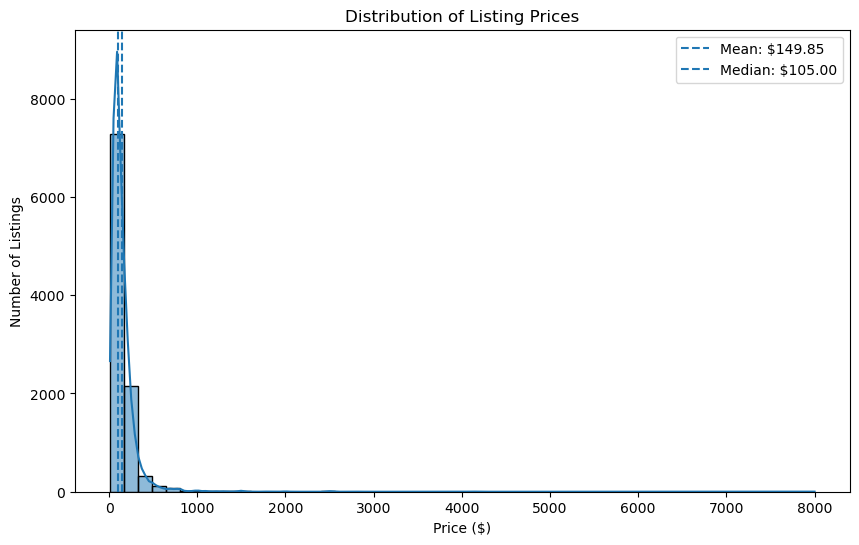

In [67]:
price_mean = df["price"].mean()
price_median = df["price"].median()
price_skewness = df["price"].skew()

print(f"Mean price: ${price_mean:.2f}")
print(f"Median price: ${price_median:.2f}")
print(f"Minimum price: ${df['price'].min():.2f}")
print(f"Maximum price: ${df['price'].max():.2f}")
print(f"Price skewness: {price_skewness:.2f}")

plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.axvline(
    price_mean,
    linestyle="--",
    label=f"Mean: ${price_mean:.2f}"
)

plt.axvline(
    price_median,
    linestyle="--",
    label=f"Median: ${price_median:.2f}"
)

plt.title("Distribution of Listing Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.legend()
plt.show()

### Finding

The price distribution is strongly right-skewed. The median listing price is approximately $105, while the mean is approximately $149.85, showing that a relatively small number of high-priced listings pull the mean above the median.

The price distribution has a skewness of approximately 14.57, confirming substantial right-skewness and the presence of extreme high-price listings.

Therefore, the median is a more representative measure of the typical listing price than the mean for this dataset.

## 2. Room Type and Borough Distribution

This analysis examines the composition of the dataset by room type and borough.

Understanding the frequency of each category helps establish which accommodation types and geographic areas dominate the dataset.

In [68]:
room_counts = (
    df["room_type"]
    .value_counts()
)

borough_counts = (
    df["borough"]
    .value_counts()
)

print("Room Type Distribution:")
display(room_counts.to_frame("listing_count"))

print("\nBorough Distribution:")
display(borough_counts.to_frame("listing_count"))

Room Type Distribution:


,listing_count
room_type,
Entire home/apt,5179
Private room,4601
Shared room,226



Borough Distribution:


,listing_count
borough,
Manhattan,4442
Brooklyn,4081
Queens,1181
Bronx,229
Staten Island,73


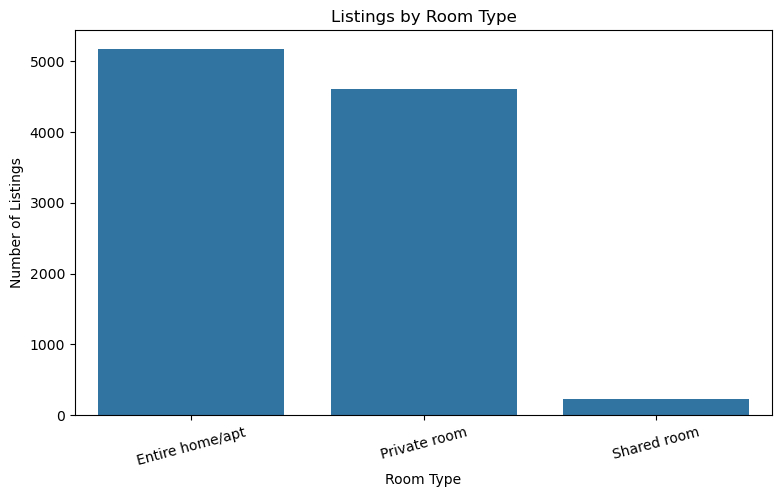

In [69]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=room_counts.index,
    y=room_counts.values
)

plt.title("Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)
plt.show()

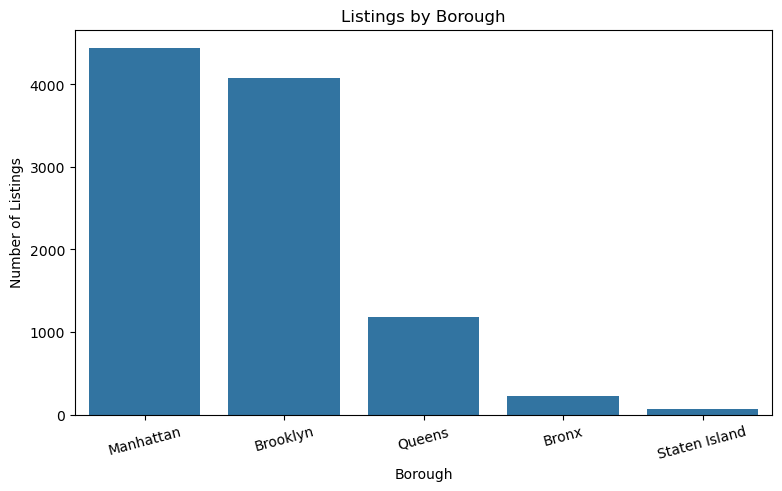

In [70]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=borough_counts.index,
    y=borough_counts.values
)

plt.title("Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)
plt.show()

### Finding

Entire home/apt is the most common room type with 5,179 listings, followed by Private room with 4,601 listings. Shared room listings are much less common.

Among the boroughs, Manhattan has the highest number of listings with 4,442 listings, making it the most represented borough in the dataset.

This indicates that the Airbnb market is primarily concentrated in Entire home/apt and Private room listings, with Manhattan accounting for the largest share of listings geographically.

## 3. Availability Distribution

The **`availability_365`** variable represents the number of days a listing is available within a 365-day period.

The distribution is examined to determine whether listings are generally available for most of the year or have more restricted availability.

Mean availability: 112.32 days
Median availability: 44.00 days

Year-round listings (365 days): 290 (2.90%)
Highly restricted listings (30 days or less): 4,689 (46.86%)


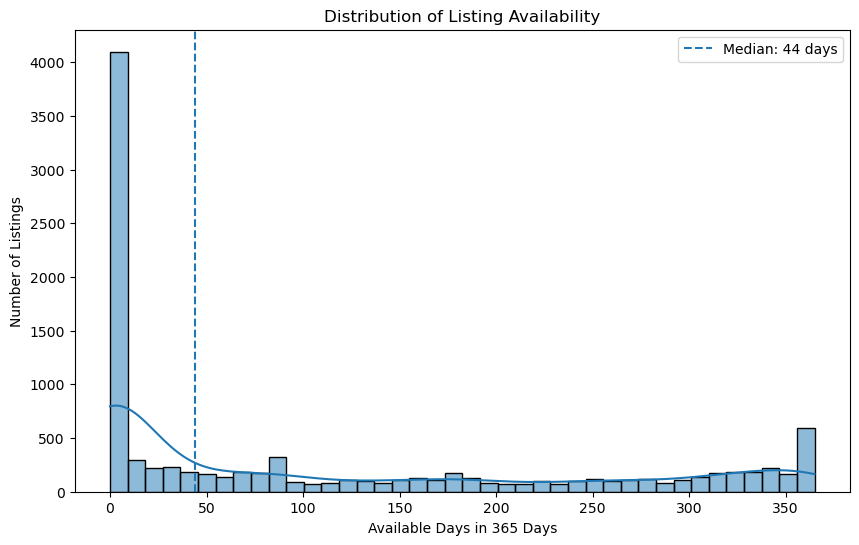

In [71]:
availability_mean = df["availability_365"].mean()
availability_median = df["availability_365"].median()

year_round = (
    df["availability_365"] == 365
).sum()

highly_restricted = (
    df["availability_365"] <= 30
).sum()

year_round_percentage = (
    year_round / len(df) * 100
)

highly_restricted_percentage = (
    highly_restricted / len(df) * 100
)

print(f"Mean availability: {availability_mean:.2f} days")
print(f"Median availability: {availability_median:.2f} days")

print(
    f"\nYear-round listings (365 days): "
    f"{year_round:,} ({year_round_percentage:.2f}%)"
)

print(
    f"Highly restricted listings (30 days or less): "
    f"{highly_restricted:,} ({highly_restricted_percentage:.2f}%)"
)

plt.figure(figsize=(10, 6))

sns.histplot(
    df["availability_365"],
    bins=40,
    kde=True
)

plt.axvline(
    availability_median,
    linestyle="--",
    label=f"Median: {availability_median:.0f} days"
)

plt.title("Distribution of Listing Availability")
plt.xlabel("Available Days in 365 Days")
plt.ylabel("Number of Listings")
plt.legend()
plt.show()

### Finding

Most listings have relatively restricted availability rather than being available year-round. Approximately 46.86% of listings have availability of 30 days or fewer, while only 2.90% are available for all 365 days.

The median availability is 44 days, indicating that a typical listing is available for only a limited portion of the year.

## 4. Price by Borough and Room Type

Listing prices are compared across boroughs and room types to identify geographic and accommodation-level pricing differences.

Median price is used as the primary comparison because the overall price distribution is strongly right-skewed.

In [72]:
borough_price = (
    df.groupby("borough")["price"]
    .agg(
        median_price="median",
        mean_price="mean",
        listing_count="count"
    )
    .sort_values(
        "median_price",
        ascending=False
    )
)

print("Price by Borough:")
display(borough_price)

highest_median_borough = borough_price["median_price"].idxmax()
highest_median_price = borough_price["median_price"].max()

print(
    f"\nBorough with the highest median price: "
    f"{highest_median_borough}"
)

print(
    f"Highest median price: "
    f"${highest_median_price:.2f}"
)

Price by Borough:


,median_price,mean_price,listing_count
borough,,,
Manhattan,150.0,193.225912,4442
Brooklyn,90.0,122.716001,4081
Queens,72.0,96.122354,1181
Staten Island,72.0,90.630137,73
Bronx,65.0,87.991266,229



Borough with the highest median price: Manhattan
Highest median price: $150.00


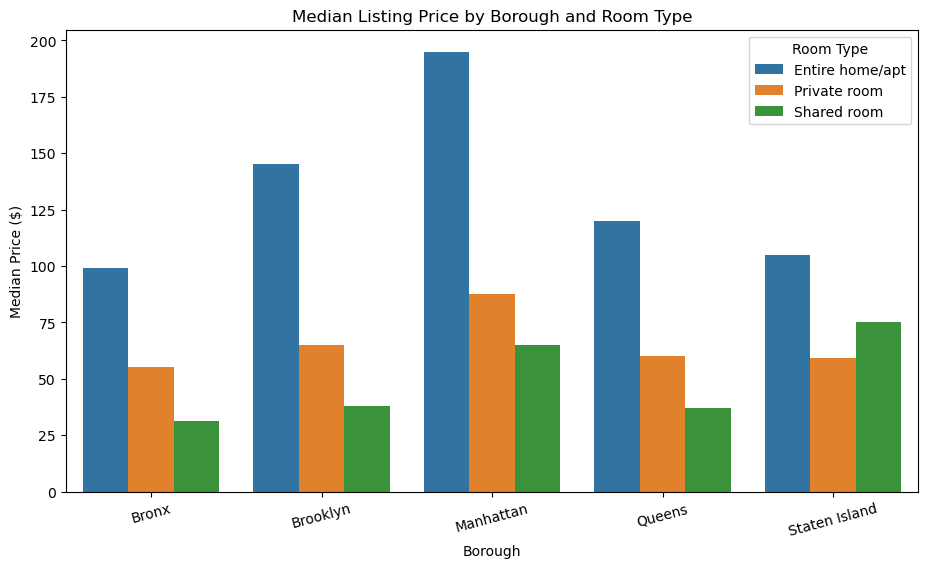

In [73]:
room_borough_price = (
    df.groupby(
        ["borough", "room_type"]
    )["price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=room_borough_price,
    x="borough",
    y="price",
    hue="room_type"
)

plt.title("Median Listing Price by Borough and Room Type")
plt.xlabel("Borough")
plt.ylabel("Median Price ($)")
plt.xticks(rotation=15)
plt.legend(title="Room Type")
plt.show()

### Finding

Median prices vary across boroughs and room types. Manhattan has the highest median listing price among the boroughs at approximately $150.

Room type also contributes to price differences, with Entire home/apt listings generally commanding higher prices than Private room and Shared room listings.

Overall, the results indicate that both location and accommodation type are associated with differences in listing prices.

## 5. Relationship Between Reviews and Rating

This analysis investigates whether listings with more reviews tend to have different ratings.

Only listings with both review counts and ratings are included because listings without reviews do not have a valid rating value in the cleaned dataset.

Both the correlation and the visual relationship are examined.

In [74]:
review_rating = df[
    [
        "number_of_reviews",
        "rating"
    ]
].dropna()

pearson_corr = (
    review_rating["number_of_reviews"]
    .corr(
        review_rating["rating"],
        method="pearson"
    )
)

spearman_corr = (
    review_rating["number_of_reviews"]
    .corr(
        review_rating["rating"],
        method="spearman"
    )
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: -0.003
Spearman correlation: -0.003


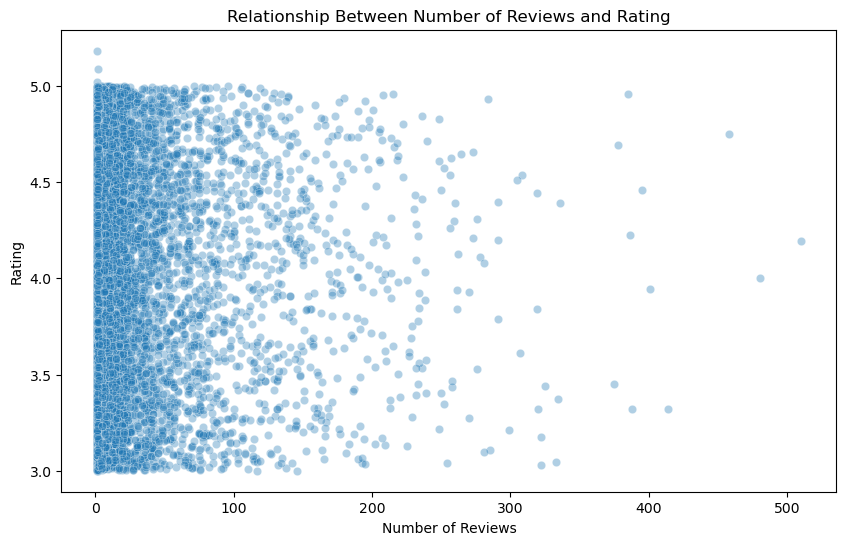

In [75]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=review_rating,
    x="number_of_reviews",
    y="rating",
    alpha=0.35
)

plt.title("Relationship Between Number of Reviews and Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.show()

### Finding

There is essentially no relationship between the number of reviews and rating. The Pearson correlation is approximately -0.003, and the Spearman correlation is also approximately -0.003.

These values are effectively zero, indicating that listings with more reviews do not systematically have higher or lower ratings in this dataset. Review volume therefore has negligible association with rating.

This result represents an association and does not imply any causal relationship between review volume and rating.

## 6. Relationship Between Price and Availability

This analysis examines whether listing price is related to the number of days a listing is available.

The objective is to determine whether expensive listings tend to have lower availability or whether price and availability show little relationship.

In [76]:
price_availability = df[
    [
        "price",
        "availability_365"
    ]
].dropna()

price_availability_corr = (
    price_availability["price"]
    .corr(
        price_availability["availability_365"],
        method="spearman"
    )
)

print(
    f"Spearman correlation between price and availability: "
    f"{price_availability_corr:.3f}"
)

Spearman correlation between price and availability: 0.093


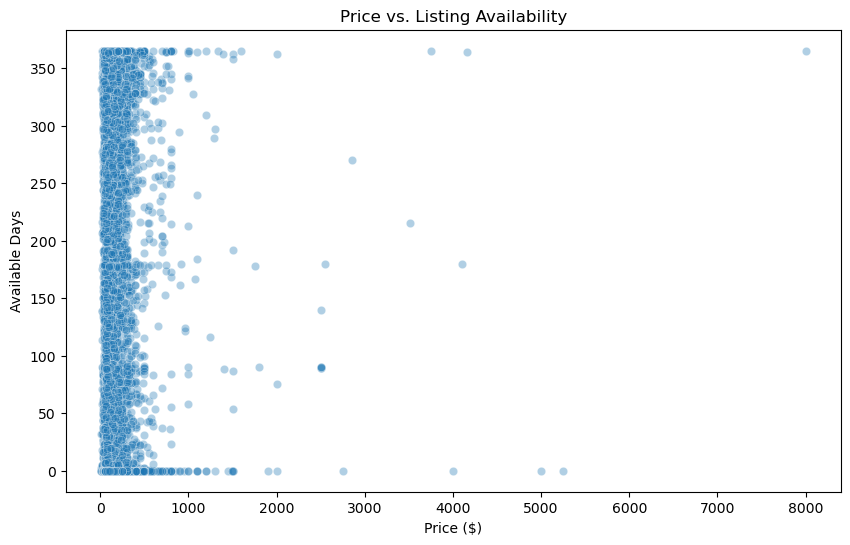

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_availability,
    x="price",
    y="availability_365",
    alpha=0.35
)

plt.title("Price vs. Listing Availability")
plt.xlabel("Price ($)")
plt.ylabel("Available Days")
plt.show()

### Finding

Price and availability show a very weak positive relationship. The Spearman correlation is approximately 0.093, indicating that higher-priced listings tend to have slightly higher availability, but the association is weak.

Therefore, price does not appear to be a strong determinant of listing availability in this dataset. The result represents an association rather than evidence of a causal relationship.

## 7. Review Activity by Room Type

The typical review activity is compared across room types using **`reviews_per_month`**.

Listings without reviews are excluded because their **`reviews_per_month`** value is missing rather than zero.

In [78]:
review_activity = df[
    df["room_type"].isin(
        ["Entire home/apt", "Private room"]
    )
    &
    df["reviews_per_month"].notna()
].copy()

room_review_summary = (
    review_activity
    .groupby("room_type")["reviews_per_month"]
    .agg(
        median_reviews_per_month="median",
        mean_reviews_per_month="mean",
        listing_count="count"
    )
    .sort_values(
        "median_reviews_per_month",
        ascending=False
    )
)

display(room_review_summary)

,median_reviews_per_month,mean_reviews_per_month,listing_count
room_type,,,
Private room,0.765,1.409481,3602
Entire home/apt,0.645,1.299990,4160


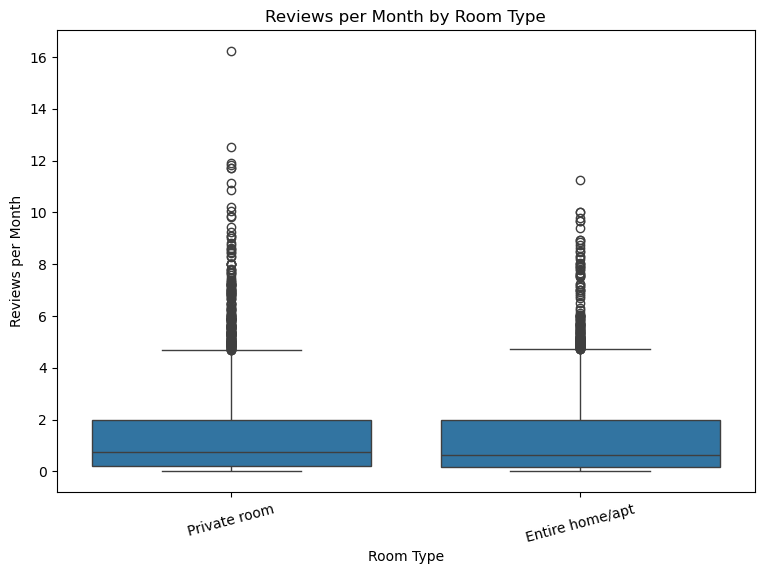

In [79]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=review_activity,
    x="room_type",
    y="reviews_per_month"
)

plt.title("Reviews per Month by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Reviews per Month")
plt.xticks(rotation=15)
plt.show()

### Finding

Private room listings have higher typical monthly review activity than Entire home/apt listings. The median `reviews_per_month` is approximately 0.765 for Private rooms compared with 0.645 for Entire home/apt listings.

This indicates that Private room listings receive slightly more monthly review activity on a typical basis in this dataset.

Listings without review activity are excluded because their `reviews_per_month` values are missing rather than zero.

## 8. Neighborhood Price and Five-Star Rating

Neighborhood-level analysis is used to identify areas with higher typical listing prices and stronger five-star rating proportions.

A minimum listing-count threshold is applied so that neighborhoods represented by only one or two listings do not dominate the ranking.

In [80]:
neighborhood_summary = (
    df.groupby("neighborhood")
    .agg(
        listing_count=("listing_id", "count"),
        average_price=("price", "mean"),
        average_five_star_percentage=(
            "five_star_percentage",
            "mean"
        )
    )
)

neighborhood_summary = (
    neighborhood_summary[
        neighborhood_summary["listing_count"] >= 10
    ]
)

top_price_neighborhoods = (
    neighborhood_summary
    .sort_values(
        "average_price",
        ascending=False
    )
    .head(10)
)

top_rating_neighborhoods = (
    neighborhood_summary
    .dropna(
        subset=["average_five_star_percentage"]
    )
    .sort_values(
        "average_five_star_percentage",
        ascending=False
    )
    .head(10)
)

print("Top 10 Neighborhoods by Average Price:")
display(top_price_neighborhoods)

print("\nTop 10 Neighborhoods by Average Five-Star Percentage:")
display(top_rating_neighborhoods)

Top 10 Neighborhoods by Average Price:


,listing_count,average_price,average_five_star_percentage
neighborhood,,,
Battery Park City,15,405.933333,75.552232
Flatiron District,19,399.421053,67.719921
Tribeca,35,383.057143,71.338916
Little Italy,30,341.933333,74.751635
Brooklyn Heights,28,283.892857,71.802052
Midtown,321,280.503115,70.355387
West Village,152,259.059211,73.260306
Cypress Hills,29,252.620690,68.264002
NoHo,16,251.312500,71.569019



Top 10 Neighborhoods by Average Five-Star Percentage:


,listing_count,average_price,average_five_star_percentage
neighborhood,,,
St. George,13,79.076923,78.950296
Cobble Hill,16,205.375000,76.094458
Bayside,11,114.727273,76.044149
Battery Park City,15,405.933333,75.552232
Springfield Gardens,21,111.904762,75.533386
Gravesend,15,69.400000,75.236206
Little Italy,30,341.933333,74.751635
Chinatown,85,169.564706,74.655234
Boerum Hill,35,160.828571,74.531445


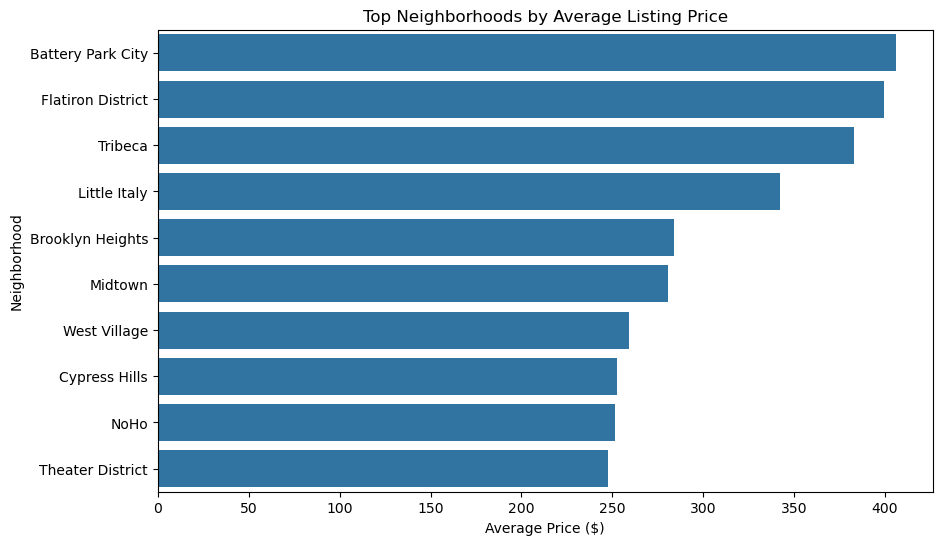

In [81]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_price_neighborhoods.reset_index(),
    y="neighborhood",
    x="average_price"
)

plt.title("Top Neighborhoods by Average Listing Price")
plt.xlabel("Average Price ($)")
plt.ylabel("Neighborhood")
plt.show()

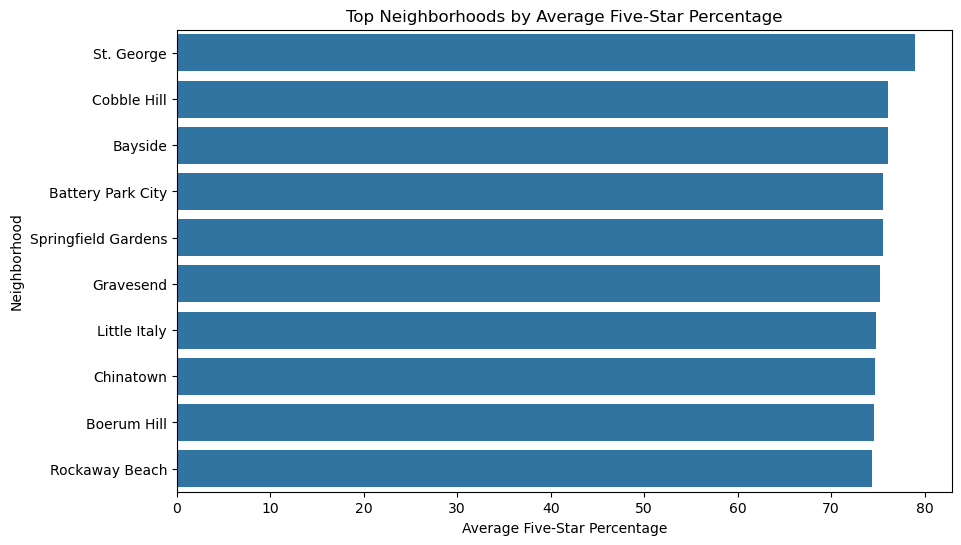

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_rating_neighborhoods.reset_index(),
    y="neighborhood",
    x="average_five_star_percentage"
)

plt.title("Top Neighborhoods by Average Five-Star Percentage")
plt.xlabel("Average Five-Star Percentage")
plt.ylabel("Neighborhood")
plt.show()

### Finding

Among neighborhoods with at least 10 listings, Battery Park City has the highest average listing price at approximately $405.93.

St. George has the highest average five-star percentage at approximately 79.08%.

The neighborhood with the highest average price is therefore different from the neighborhood with the highest five-star percentage, indicating that higher prices do not necessarily correspond to higher five-star proportions.

The minimum listing threshold improves the reliability of these comparisons by preventing neighborhoods with very few listings from dominating the rankings.

## 9. Single-Listing vs Multi-Property Hosts

Hosts are compared based on the host portfolio classification created in Part 2.

The analysis focuses on whether single-listing and multi-property hosts show different pricing and availability patterns.

In [83]:
host_summary = (
    df.groupby("host_type")
    .agg(
        listing_count=("listing_id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_availability=("availability_365", "median"),
        mean_availability=("availability_365", "mean")
    )
)

display(host_summary)

,listing_count,median_price,mean_price,median_availability,mean_availability
host_type,,,,,
Multi-property host,1663,100.0,154.308779,250.0,210.567048
Single-listing host,8343,109.0,148.961345,20.0,92.735946


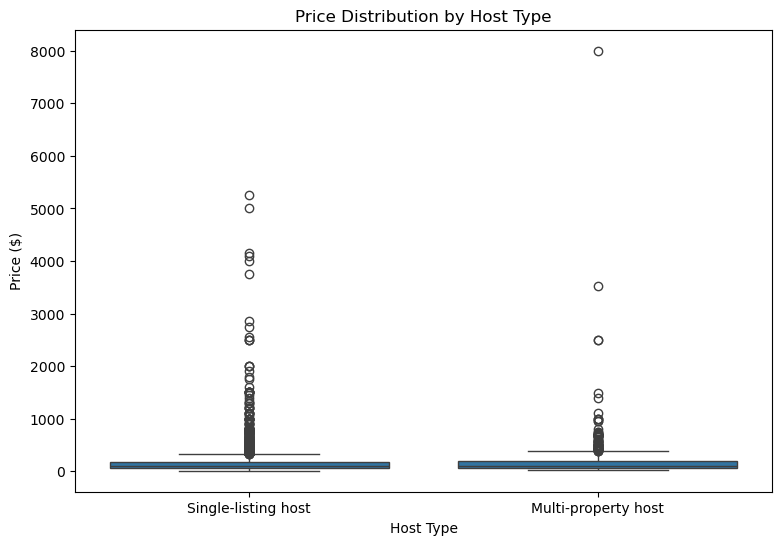

In [84]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="host_type",
    y="price"
)

plt.title("Price Distribution by Host Type")
plt.xlabel("Host Type")
plt.ylabel("Price ($)")
plt.show()

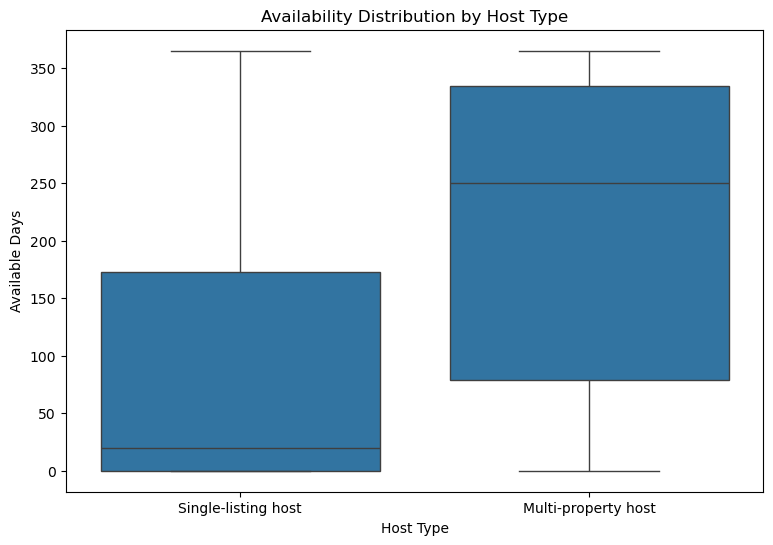

In [85]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="host_type",
    y="availability_365"
)

plt.title("Availability Distribution by Host Type")
plt.xlabel("Host Type")
plt.ylabel("Available Days")
plt.show()

### Finding

Multi-property hosts show substantially higher availability than single-listing hosts. The median availability is approximately 250 days for multi-property hosts compared with 20 days for single-listing hosts.

In terms of price, the median is approximately $100 for multi-property hosts and $109 for single-listing hosts, indicating only a small difference in typical listing prices.

Overall, multi-property hosts appear to maintain substantially greater availability, while their typical prices are broadly similar to those of single-listing hosts.

These results describe observed differences between host groups and should not be interpreted as evidence that host type itself causes these differences.

## 10. Geographic Clustering of High-Price and High-Rating Listings

Latitude and longitude are used to visualize the geographic distribution of listings.

The analysis highlights listings in the upper quartile of price and five-star percentage to identify areas where higher-priced or highly rated listings are concentrated.

In [86]:
price_threshold = df["price"].quantile(0.75)

rating_threshold = (
    df["five_star_percentage"]
    .dropna()
    .quantile(0.75)
)

df["high_price_flag"] = (
    df["price"] >= price_threshold
)

df["high_rating_flag"] = (
    df["five_star_percentage"] >= rating_threshold
)

print(f"High-price threshold: ${price_threshold:.2f}")
print(
    f"High-rating threshold: "
    f"{rating_threshold:.2f}%"
)

High-price threshold: $179.00
High-rating threshold: 76.40%


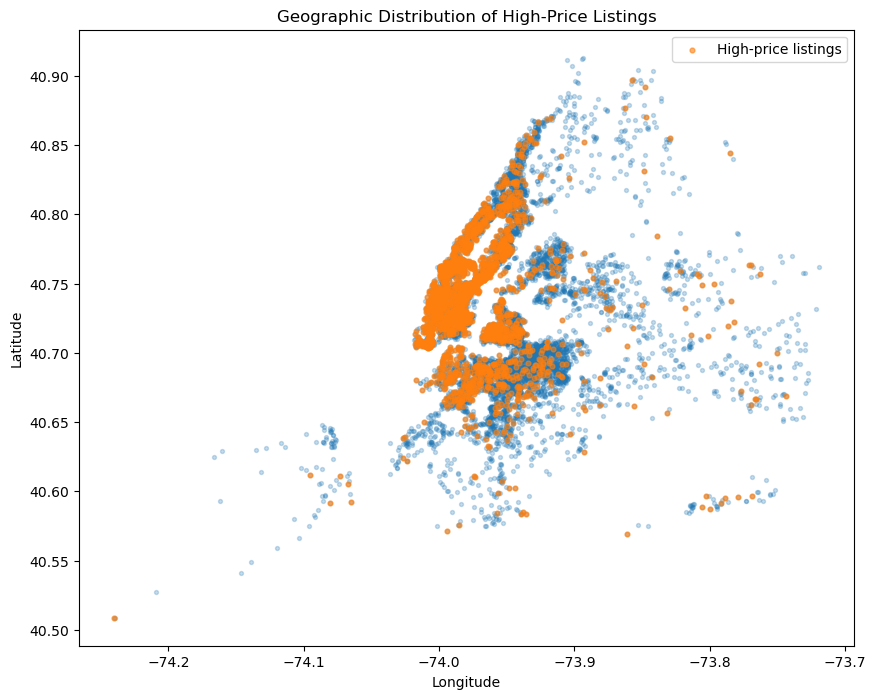

In [87]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=8,
    alpha=0.25
)

high_price = df[
    df["high_price_flag"]
]

plt.scatter(
    high_price["longitude"],
    high_price["latitude"],
    s=12,
    alpha=0.6,
    label="High-price listings"
)

plt.title("Geographic Distribution of High-Price Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

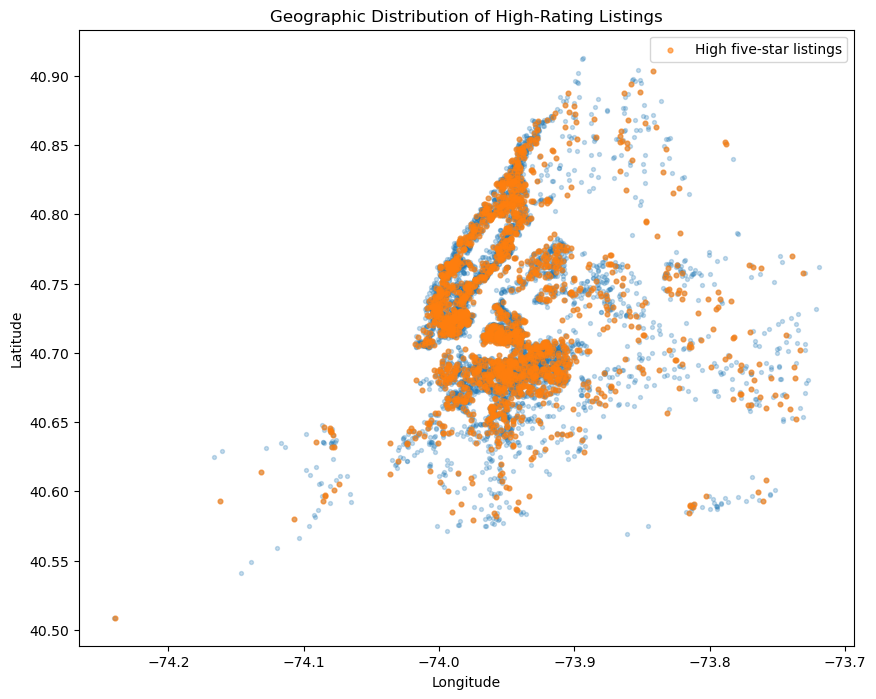

In [88]:
rating_map_data = df[
    df["five_star_percentage"].notna()
]

plt.figure(figsize=(10, 8))

plt.scatter(
    rating_map_data["longitude"],
    rating_map_data["latitude"],
    s=8,
    alpha=0.25
)

high_rating = rating_map_data[
    rating_map_data["high_rating_flag"]
]

plt.scatter(
    high_rating["longitude"],
    high_rating["latitude"],
    s=12,
    alpha=0.6,
    label="High five-star listings"
)

plt.title("Geographic Distribution of High-Rating Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

### Finding

The geographic visualizations show that listings are concentrated within the main urban areas rather than being evenly distributed across the full geographic range.

High-price and high-five-star listings are distributed across multiple geographic areas, with some visible concentration in specific parts of the city.

The visualization indicates geographic variation in listing price and five-star performance, but it does not establish that location directly causes differences in price or ratings.

## 11. Listing Additions Over Time

The **`listing_added`** date is analyzed to understand how the listing inventory changed over time.

Monthly listing additions are examined to identify periods with unusually high or low listing activity.

In [89]:
monthly_listings = (
    df.set_index("listing_added")
    .resample("MS")
    .size()
)

print("Monthly listing additions:")
display(
    monthly_listings
    .to_frame("listings_added")
    .tail(15)
)

Monthly listing additions:


,listings_added
listing_added,
2019-08-01,0
2019-09-01,0
2019-10-01,0
2019-11-01,0
2019-12-01,0
2020-01-01,0
2020-02-01,1
2020-03-01,0
2020-04-01,0


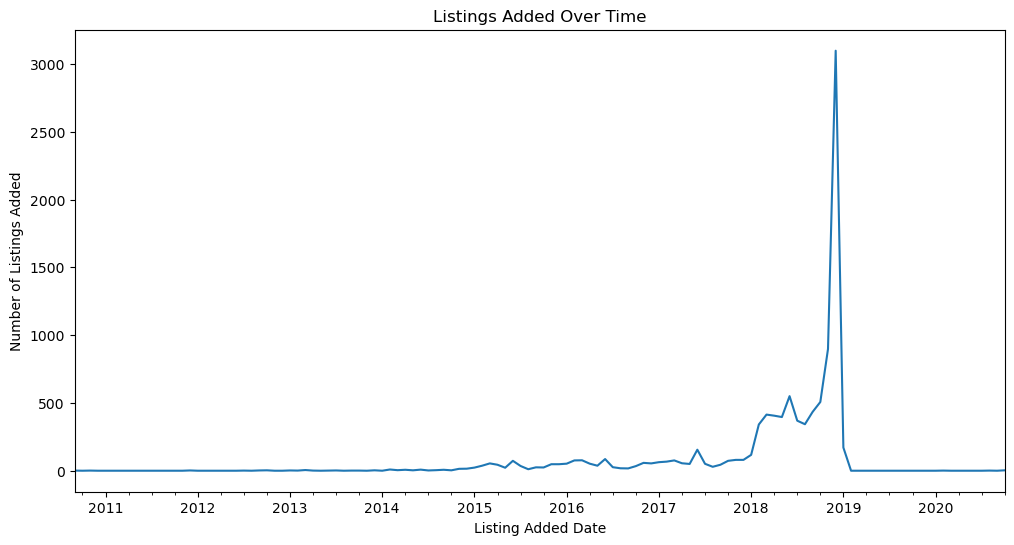

In [90]:
plt.figure(figsize=(12, 6))

monthly_listings.plot()

plt.title("Listings Added Over Time")
plt.xlabel("Listing Added Date")
plt.ylabel("Number of Listings Added")
plt.show()

In [91]:
monthly_peak = monthly_listings.idxmax()
monthly_peak_count = monthly_listings.max()

print(
    f"Peak listing-addition month: "
    f"{monthly_peak.strftime('%Y-%m')}"
)

print(
    f"Listings added during peak month: "
    f"{monthly_peak_count}"
)

Peak listing-addition month: 2018-12
Listings added during peak month: 3098


### Finding

Listing additions varied substantially over the observed period, with a clear concentration of new listings toward the end of 2018.

December 2018 recorded the highest number of listing additions, with 3,098 listings added.

This indicates that listing growth was not evenly distributed over time, with the strongest listing-creation activity occurring in December 2018.

## 12. Review Recency and Availability

The **`days_since_last_review`** feature is used to examine whether recently reviewed listings have different availability patterns.

A lower value of **`days_since_last_review`** represents a more recent review.

In [92]:
recency_availability = df[
    [
        "days_since_last_review",
        "availability_365"
    ]
].dropna()

recency_corr = (
    recency_availability[
        "days_since_last_review"
    ]
    .corr(
        recency_availability[
            "availability_365"
        ],
        method="spearman"
    )
)

print(
    "Spearman correlation between "
    f"review recency and availability: {recency_corr:.3f}"
)

Spearman correlation between review recency and availability: -0.464


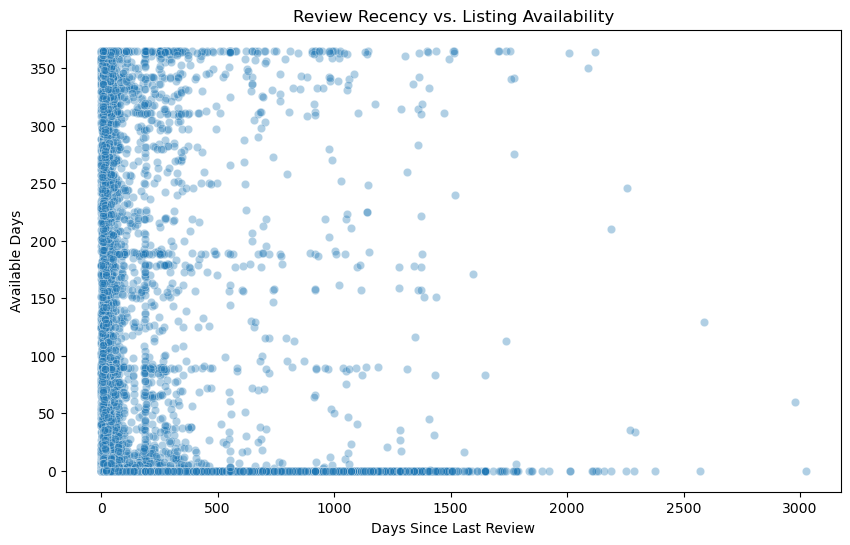

In [93]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=recency_availability,
    x="days_since_last_review",
    y="availability_365",
    alpha=0.35
)

plt.title("Review Recency vs. Listing Availability")
plt.xlabel("Days Since Last Review")
plt.ylabel("Available Days")
plt.show()

### Finding

There is a moderate negative relationship between `days_since_last_review` and `availability_365`, with a Spearman correlation of approximately -0.464.

Because a lower `days_since_last_review` value represents a more recent review, the negative relationship suggests that listings with more recent reviews tend to have higher availability.

This indicates an association between recent review activity and availability, but it does not establish that recent reviews cause higher availability.

## 13. Never-Reviewed Listings

Listings with zero reviews are separated from listings with at least one review using the **`has_reviews`** feature created in Part 2.

The analysis measures the proportion of never-reviewed listings and compares their basic characteristics with reviewed listings.

In [94]:
never_reviewed_count = (
    df["has_reviews"] == 0
).sum()

reviewed_count = (
    df["has_reviews"] == 1
).sum()

total_listings = len(df)

never_reviewed_percentage = (
    never_reviewed_count
    /
    total_listings
    *
    100
)

print(
    f"Never-reviewed listings: "
    f"{never_reviewed_count:,}"
)

print(
    f"Reviewed listings: "
    f"{reviewed_count:,}"
)

print(
    f"Never-reviewed percentage: "
    f"{never_reviewed_percentage:.2f}%"
)

Never-reviewed listings: 2,074
Reviewed listings: 7,932
Never-reviewed percentage: 20.73%


In [95]:
review_status_summary = (
    df.groupby("has_reviews")
    .agg(
        listing_count=("listing_id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        median_availability=(
            "availability_365",
            "median"
        )
    )
)

review_status_summary.index = [
    "Never reviewed",
    "Has reviews"
]

display(review_status_summary)

,listing_count,median_price,mean_price,median_availability
Never reviewed,2074,119.0,189.751688,7.0
Has reviews,7932,104.5,139.416919,54.0


In [96]:
borough_review = (
    pd.crosstab(
        df["borough"],
        df["has_reviews"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

borough_review.columns = [
    "Never reviewed (%)",
    "Has reviews (%)"
]

display(
    borough_review.sort_values(
        "Never reviewed (%)",
        ascending=False
    )
)

,Never reviewed (%),Has reviews (%)
borough,,
Manhattan,23.10,76.90
Bronx,19.65,80.35
Queens,19.64,80.36
Brooklyn,18.65,81.35
Staten Island,13.70,86.30


### Finding

There are 2,074 listings with zero reviews, representing approximately 20.73% of the cleaned dataset.

Never-reviewed listings have a median price of approximately $119, compared with $104.50 for listings with at least one review. Their median availability is 7 days, compared with 54 days for reviewed listings.

Manhattan has the highest share of never-reviewed listings at approximately 23.10%.

Overall, never-reviewed listings tend to have slightly higher prices and substantially lower availability than reviewed listings in this dataset.

## 14. Review Data Quality Assessment

The final EDA check investigates whether review-related fields are internally consistent.

The analysis focuses on cases where review counts conflict with related fields such as rating, five-star proportion, monthly reviews, or last review date.

In [97]:
review_quality_checks = {
    "Zero reviews but rating exists": (
        (df["number_of_reviews"] == 0)
        &
        df["rating"].notna()
    ).sum(),

    "Zero reviews but 5_stars exists": (
        (df["number_of_reviews"] == 0)
        &
        df["5_stars"].notna()
    ).sum(),

    "Zero reviews but reviews_per_month exists": (
        (df["number_of_reviews"] == 0)
        &
        df["reviews_per_month"].notna()
    ).sum(),

    "Zero reviews but last_review exists": (
        (df["number_of_reviews"] == 0)
        &
        df["last_review"].notna()
    ).sum(),

    "Reviews exist but rating is missing": (
        (df["number_of_reviews"] > 0)
        &
        df["rating"].isna()
    ).sum(),

    "Reviews exist but 5_stars is missing": (
        (df["number_of_reviews"] > 0)
        &
        df["5_stars"].isna()
    ).sum(),

    "Reviews exist but reviews_per_month is missing": (
        (df["number_of_reviews"] > 0)
        &
        df["reviews_per_month"].isna()
    ).sum(),

    "Reviews exist but last_review is missing": (
        (df["number_of_reviews"] > 0)
        &
        df["last_review"].isna()
    ).sum()
}

review_quality_summary = (
    pd.Series(
        review_quality_checks,
        name="record_count"
    )
)

display(
    review_quality_summary.to_frame()
)

,record_count
Zero reviews but rating exists,0
Zero reviews but 5_stars exists,0
Zero reviews but reviews_per_month exists,0
Zero reviews but last_review exists,0
Reviews exist but rating is missing,0
Reviews exist but 5_stars is missing,0
Reviews exist but reviews_per_month is missing,0
Reviews exist but last_review is missing,0


In [98]:
print("Total suspicious review-field patterns:")

total_review_inconsistencies = (
    review_quality_summary.sum()
)

print(
    total_review_inconsistencies
)

if total_review_inconsistencies == 0:
    print(
        "No suspicious review-field inconsistencies "
        "were detected."
    )
else:
    print(
        "Review-related inconsistencies require "
        "further investigation."
    )

Total suspicious review-field patterns:
0
No suspicious review-field inconsistencies were detected.


### Finding

No suspicious review-data inconsistencies were detected in the dataset.

Listings with zero reviews consistently have the expected missing review-dependent fields, while listings with reviews contain the corresponding review information. Therefore, there is no evidence of a systematic mismatch between review counts and the supporting review variables.

## 15. Final EDA Audit

The final audit confirms that all variables required for Part 3 are available and that the main analytical outputs were successfully generated.

This provides a final checkpoint before moving from exploratory analysis to research-question analysis and business interpretation.

In [99]:
eda_required_columns = [
    "price",
    "room_type",
    "borough",
    "availability_365",
    "number_of_reviews",
    "rating",
    "reviews_per_month",
    "neighborhood",
    "five_star_percentage",
    "host_type",
    "latitude",
    "longitude",
    "listing_added",
    "days_since_last_review",
    "has_reviews",
    "last_review",
    "5_stars"
]

missing_eda_columns = [
    col
    for col in eda_required_columns
    if col not in df.columns
]

eda_audit = pd.DataFrame({
    "feature": eda_required_columns,
    "exists": [
        col in df.columns
        for col in eda_required_columns
    ],
    "missing_values": [
        df[col].isna().sum()
        if col in df.columns
        else np.nan
        for col in eda_required_columns
    ]
})

display(eda_audit)

print(
    "\nMissing required EDA columns:",
    missing_eda_columns
)

if not missing_eda_columns:
    print(
        "FINAL EDA AUDIT: PASS"
    )
    print(
        "All required variables are available for Part 3."
    )
else:
    print(
        "FINAL EDA AUDIT: REVIEW REQUIRED"
    )

,feature,exists,missing_values
0,price,True,0
1,room_type,True,0
2,borough,True,0
3,availability_365,True,0
4,number_of_reviews,True,0
5,rating,True,2074
6,reviews_per_month,True,2074
7,neighborhood,True,0
8,five_star_percentage,True,2074
9,host_type,True,0



Missing required EDA columns: []
FINAL EDA AUDIT: PASS
All required variables are available for Part 3.


## Part 3 Final Summary

The exploratory analysis examined the Airbnb listings from multiple perspectives.

The analysis covered:

- overall price distribution and skewness,
- room type and borough composition,
- listing availability,
- price differences across boroughs and room types,
- the relationship between reviews and ratings,
- the relationship between price and availability,
- review activity across room types,
- neighborhood-level pricing and five-star patterns,
- differences between single-listing and multi-property hosts,
- geographic clustering of high-price and high-rating listings,
- listing additions over time,
- review recency and availability,
- characteristics of never-reviewed listings,
- and potential inconsistencies in review-related fields.

The purpose of the EDA is to identify meaningful patterns that can guide the deeper research questions and business interpretations in the next stage of the project.

The analysis does not treat correlation as causation and does not interpret proxy metrics created in Part 2 as verified business measures.